In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings,itertools
from scipy import stats
from sklearn.feature_selection import mutual_info_classif,mutual_info_regression
import os
import re

def safe_name(t):
    return re.sub(r'[<>:"/\\|?*]', '-', t)

os.makedirs("Graphs", exist_ok=True)
_original_show = plt.show
plt.show = lambda *args, **kwargs: (plt.savefig(f"Graphs/{safe_name(plt.gca().get_title() or f'Figure_{plt.gcf().number}')}.png", dpi=150, bbox_inches="tight"), _original_show(*args, **kwargs))

fontname='Times New Roman'
if fontname not in {f.name for f in fm.fontManager.ttflist}:
    warnings.warn(f"{fontname} not found, using DejaVu Serif")
    fontname='DejaVu Serif'

maxcols=3
cellwidth=5
cellheight=4
singlesize=(8,5)
topn=6

def setGraphStyle():
    sns.set_style('whitegrid')
    plt.rcParams['font.family']=fontname
    plt.rcParams['font.size']=15
    plt.rcParams['axes.labelweight']='bold'
    plt.rcParams['axes.titlesize']=15
    plt.rcParams['figure.dpi']=150

def gridAxes(n):
    ncols=min(maxcols,n)
    nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(cellwidth*ncols,cellheight*nrows))
    axes=np.array(axes).reshape(-1)
    return fig,axes

def showFig(fig):
    fig.tight_layout()
    plt.show()
    plt.close(fig)

def datasetOverview(df):
    rows,cols=df.shape
    names=df.columns.tolist()
    types=df.dtypes.astype(str).tolist()
    return rows,cols,names,types

def checkMissing(df):
    miss=df.isnull().sum()
    dup=df.duplicated().sum()
    single=[c for c in df.columns if df[c].nunique()==1]
    empty=[c for c in df.columns if df[c].isnull().all()]
    mixed=[]
    obj=df.select_dtypes(include=['object','string']).columns
    for c in obj:
        if c in empty:
            continue
        s=df[c].dropna().astype(str)
        if s.empty:
            continue
        if s.str.match(r'^-?\d+(\.\d+)?$').all():
            mixed.append(c)
    return miss,dup,single,empty,mixed

def analyzeNumeric(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    summary=num.describe().T
    summary=summary.rename(columns={'mean':'Mean','std':'Std','min':'Min','max':'Max','50%':'Median','25%':'Q1','75%':'Q3'})
    summary['Mode']=num.mode().iloc[0]
    summary['Range']=summary['Max']-summary['Min']
    summary['Skewness']=num.skew()
    summary['Kurtosis']=num.kurt()
    cols=['Mean','Median','Mode','Std','Min','Max','Q1','Q3','Range','Skewness','Kurtosis']
    return summary[cols]

def analyzeCategorical(df):
    cat=df.select_dtypes(include=['object','string','category'])
    if cat.empty:
        return None
    data=[]
    for c in cat.columns:
        unique=cat[c].nunique()
        mode=cat[c].mode()
        top=mode.iloc[0] if not mode.empty else None
        freq=cat[c].value_counts().iloc[0] if not cat[c].value_counts().empty else 0
        data.append([c,unique,top,freq])
    return pd.DataFrame(data,columns=['Column','Unique','Top Value','Frequency'])

def analyzeNormality(df,alpha=0.05):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    rows=[]
    for c in num.columns:
        data=num[c].dropna()
        if len(data)<3:
            continue
        sample=data.sample(min(len(data),5000),random_state=42)
        statval,p=stats.shapiro(sample)
        rows.append([c,statval,p,'Normal' if p>alpha else 'Not Normal'])
    return pd.DataFrame(rows,columns=['Column','Statistic','P-Value','Result'])

def mutualInfoAnalysis(df,target):
    if target not in df.columns:
        return None
    num=df.select_dtypes(include=['number']).drop(columns=[target],errors='ignore')
    if num.empty:
        return None
    X=num.fillna(num.median())
    y=df[target]
    if y.dtype=='object' or str(y.dtype)=='category' or y.nunique()<20:
        yenc=y.astype('category').cat.codes
        mi=mutual_info_classif(X,yenc,random_state=42)
    else:
        mi=mutual_info_regression(X,y,random_state=42)
    return pd.DataFrame({'Feature':num.columns,'Mutual Information':mi}).sort_values('Mutual Information',ascending=False).reset_index(drop=True)

def detectOutliers(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    data=[]
    for c in num.columns:
        q1=num[c].quantile(0.25)
        q3=num[c].quantile(0.75)
        iqr=q3-q1
        low=q1-1.5*iqr
        high=q3+1.5*iqr
        count=((num[c]<low)|(num[c]>high)).sum()
        data.append([c,count])
    return pd.DataFrame(data,columns=['Column','Outlier Count'])

def correlationAnalysis(df):
    num=df.select_dtypes(include=['number'])
    return num.corr() if not num.empty else None

def highCorrFeatures(df,limit=0.8):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    corr=num.corr().abs()
    pairs=[]
    for i in range(len(corr.columns)):
        for j in range(i+1,len(corr.columns)):
            val=corr.iloc[i,j]
            if val>=limit:
                pairs.append([corr.columns[i],corr.columns[j],val])
    return pd.DataFrame(pairs,columns=['Feature1','Feature2','Correlation'])

def classDistribution(df,target):
    return df[target].value_counts() if target in df.columns else None

def plotTargetOverview(df,target,maxcats=30):
    if target not in df.columns:
        print(f'plotTargetOverview: {target} not in dataframe, skipped')
        return
    nunique=df[target].nunique()
    if df[target].dtype.name in ('object','category') or nunique<=maxcats:
        plotClassDistribution(df,target)
    else:
        print(f'plotTargetOverview: target has {nunique} unique values, treating as continuous - showing distribution histogram instead of class bars')
        plotHistogram(df,cols=[target])

def plotClassDistribution(df,target,maxcats=30):
    setGraphStyle()
    if target not in df.columns:
        print(f'plotClassDistribution: {target} not in dataframe, skipped')
        return
    counts=df[target].value_counts()
    if len(counts)>maxcats:
        print(f'plotClassDistribution: target has {len(counts)} unique values (>{maxcats}), skipped - this looks like a continuous target, use plotHistogram instead')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(counts.index.astype(str),counts.values,color='#4C72B0')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel(target)
    ax.set_ylabel('Count')
    ax.set_title(f'Class Distribution: {target}')
    showFig(fig)

def selectImportantFeatures(df,target=None,n=topn,midf=None):
    num=df.select_dtypes(include=['number'])
    if target is not None and target in num.columns:
        num=num.drop(columns=[target])
    if num.empty:
        return []
    if target is not None and target in df.columns:
        mi=midf if midf is not None else mutualInfoAnalysis(df,target)
        if mi is not None and not mi.empty:
            return mi['Feature'].head(n).tolist()
    return num.var().sort_values(ascending=False).head(n).index.tolist()

def plotHistogram(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotHistogram: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].hist(num[c].dropna(),bins=30,color='#4C72B0',edgecolor='white')
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Histogram of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBoxplot(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotBoxplot: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].boxplot(num[c].dropna(),patch_artist=True,boxprops=dict(facecolor='#DD8452'))
        axes[i].set_ylabel(c)
        axes[i].set_title(f'Boxplot of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBargraph(df,cols=None):
    setGraphStyle()
    cat=df.select_dtypes(include=['object','string','category'])
    if cols is not None:
        cat=cat[[c for c in cols if c in cat.columns]]
    if cat.empty:
        print('plotBargraph: no categorical columns, skipped')
        return
    fig,axes=gridAxes(len(cat.columns))
    for i,c in enumerate(cat.columns):
        vc=cat[c].value_counts().head(15)
        axes[i].bar(vc.index.astype(str),vc.values,color='#55A868')
        axes[i].tick_params(axis='x',rotation=45,labelsize=10)
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'Bar Chart of {c}')
    for j in range(len(cat.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotScatter(df,pairs=None,maxpairs=6):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    cols=list(num.columns)
    if len(cols)<2:
        print('plotScatter: fewer than 2 numeric columns, skipped')
        return
    if pairs is None:
        pairs=list(itertools.combinations(cols,2))[:maxpairs]
    fig,axes=gridAxes(len(pairs))
    for i,(a,b) in enumerate(pairs):
        axes[i].scatter(num[a],num[b],alpha=0.6,color='#8172B2',edgecolor='white',linewidth=0.3)
        axes[i].set_xlabel(a)
        axes[i].set_ylabel(b)
        axes[i].set_title(f'{a} vs {b}')
    for j in range(len(pairs),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotHeatmap(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.shape[1]<2:
        print('plotHeatmap: fewer than 2 numeric columns, skipped')
        return
    corr=num.corr()
    fig,ax=plt.subplots(figsize=singlesize)
    sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',square=True,cbar_kws={'label':'Correlation'},ax=ax,annot_kws={'fontsize':9,'fontname':fontname})
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.tick_params(axis='y',rotation=0,labelsize=10)
    ax.set_xlabel('Features')
    ax.set_ylabel('Features')
    ax.set_title('Correlation Heatmap')
    showFig(fig)

def plotMissingValues(df):
    setGraphStyle()
    miss=df.isnull().sum()
    miss=miss[miss>0].sort_values(ascending=False)
    if miss.empty:
        print('plotMissingValues: no missing values, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(miss.index.astype(str),miss.values,color='#C44E52')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing Count')
    ax.set_title('Missing Values by Column')
    showFig(fig)

def plotOutliers(df):
    setGraphStyle()
    out=detectOutliers(df)
    if out is None or out['Outlier Count'].sum()==0:
        print('plotOutliers: no outliers detected, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(out['Column'],out['Outlier Count'],color='#DD8452')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Outlier Count')
    ax.set_title('Outlier Count per Column (IQR method)')
    showFig(fig)

def generateCorePlots(df,target=None,n=topn,midf=None):
    important=selectImportantFeatures(df,target,n,midf=midf)
    if target is not None:
        plotTargetOverview(df,target)
    plotHeatmap(df)
    plotHistogram(df,cols=important)
    plotBoxplot(df,cols=important)

def generateAllPlots(df,target=None,n=topn,midf=None):
    plotMissingValues(df)
    generateCorePlots(df,target,n,midf=midf)
    plotOutliers(df)
    plotBargraph(df)
    plotScatter(df)

def edaSummary(df,target=None,full=False,n=topn):
    rows,cols,names,types=datasetOverview(df)
    miss,dup,single,empty,mixed=checkMissing(df)
    mi=mutualInfoAnalysis(df,target) if target is not None else None
    summary={"Rows":rows,"Columns":cols,"Column Names":names,"Data Types":types,"Missing Values":miss,
    "Duplicate Rows":dup,"Single Value Columns":single,"Empty Columns":empty,"Mixed Type Columns":mixed,
    "Numerical Summary":analyzeNumeric(df),"Categorical Summary":analyzeCategorical(df),
    "Normality Test":analyzeNormality(df),
    "Outlier Summary":detectOutliers(df),"Correlation Matrix":correlationAnalysis(df),
    "Highly Correlated Features":highCorrFeatures(df)}
    if target is not None:
        summary["Class Distribution"]=classDistribution(df,target)
        summary["Mutual Information"]=mi
    print('----- EDA Summary -----')
    for k,v in summary.items():
        print(f'{k}:')
        print(v)
        print()
    print('----- Generating Plots -----')
    if full:
        generateAllPlots(df,target,n,midf=mi)
    else:
        generateCorePlots(df,target,n,midf=mi)
    return summary

In [2]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer

def preprocessData(df,tgt,dc=None):
    df=df.copy()
    df.columns=df.columns.str.strip()
    tgt=tgt.strip()
    if dc:
        df=df.drop(columns=[c for c in dc if c in df.columns])
    df=df.dropna(subset=[tgt])
    miss,dup,single,empty,mixed=checkMissing(df)
    df=df.drop(columns=list(set(empty+single)),errors='ignore')
    df=df.drop_duplicates()
    nc=df.select_dtypes(include='number').columns.tolist()
    cc=df.select_dtypes(include=['object','string','category']).columns.tolist()
    if tgt in nc:nc.remove(tgt)
    if tgt in cc:cc.remove(tgt)
    if nc:df[nc]=SimpleImputer(strategy='median').fit_transform(df[nc])
    if cc:
        df[cc]=SimpleImputer(strategy='most_frequent').fit_transform(df[cc])
        for c in cc:df[c]=LabelEncoder().fit_transform(df[c].astype(str))
    enc=None
    if df[tgt].dtype=='object' or str(df[tgt].dtype)=='category':
        enc=LabelEncoder()
        df[tgt]=enc.fit_transform(df[tgt].astype(str))
    if nc:df[nc]=StandardScaler().fit_transform(df[nc])
    return df,enc

In [3]:
import pandas as pd
col_Labels=["ID","Diagnosis","radius1","texture1","perimeter1","area1","smoothness1"
            ,"compactness1","concavity1","concave_points1","symmetry1","fractal_dimension1"
           ,"radius2","texture2","perimeter2","area2","smoothness2"
            ,"compactness2","concavity2","concave_points2","symmetry2","fractal_dimension2"
           ,"radius3","texture3","perimeter3","area3","smoothness3"
            ,"compactness3","concavity3","concave_points3","symmetry3","fractal_dimension3"]
df=pd.read_csv("breast_cancer/wdbc.data",header=None,sep=',',names=col_Labels)
df.head

<bound method NDFrame.head of            ID Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0      842302         M    17.99     10.38      122.80  1001.0      0.11840   
1      842517         M    20.57     17.77      132.90  1326.0      0.08474   
2    84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3    84348301         M    11.42     20.38       77.58   386.1      0.14250   
4    84358402         M    20.29     14.34      135.10  1297.0      0.10030   
..        ...       ...      ...       ...         ...     ...          ...   
564    926424         M    21.56     22.39      142.00  1479.0      0.11100   
565    926682         M    20.13     28.25      131.20  1261.0      0.09780   
566    926954         M    16.60     28.08      108.30   858.1      0.08455   
567    927241         M    20.60     29.33      140.10  1265.0      0.11780   
568     92751         B     7.76     24.54       47.92   181.0      0.05263   

     compactness1  co

In [4]:
target='Diagnosis'
df,enc=preprocessData(df,target,dc=['ID'])
print(df[target].unique())
df.head()

[1 0]


,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,1,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


----- EDA Summary -----
Rows:
569

Columns:
31

Column Names:
['Diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']

Data Types:
['int64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64']

Missing Values:
Diagnosis             0
radius1               0
texture1              0
perimeter1            0
area1                 0

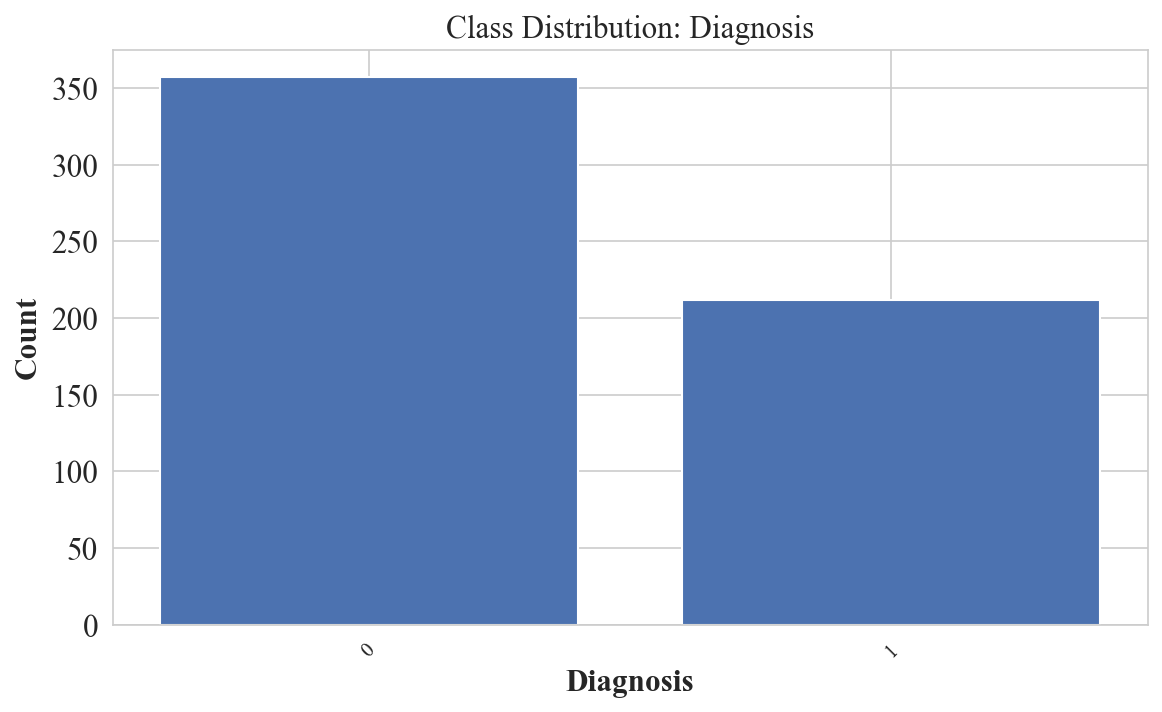

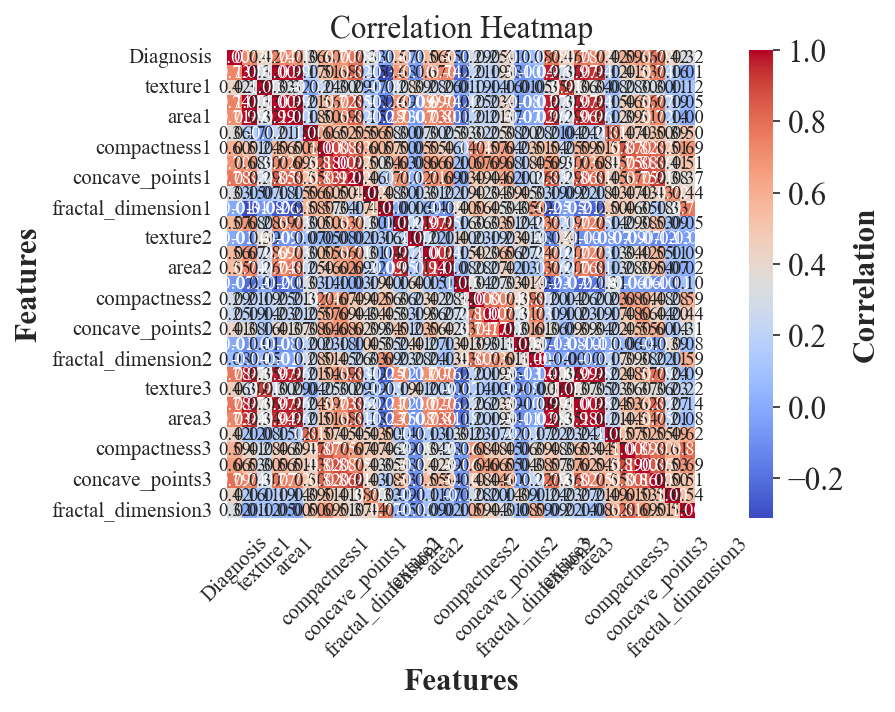

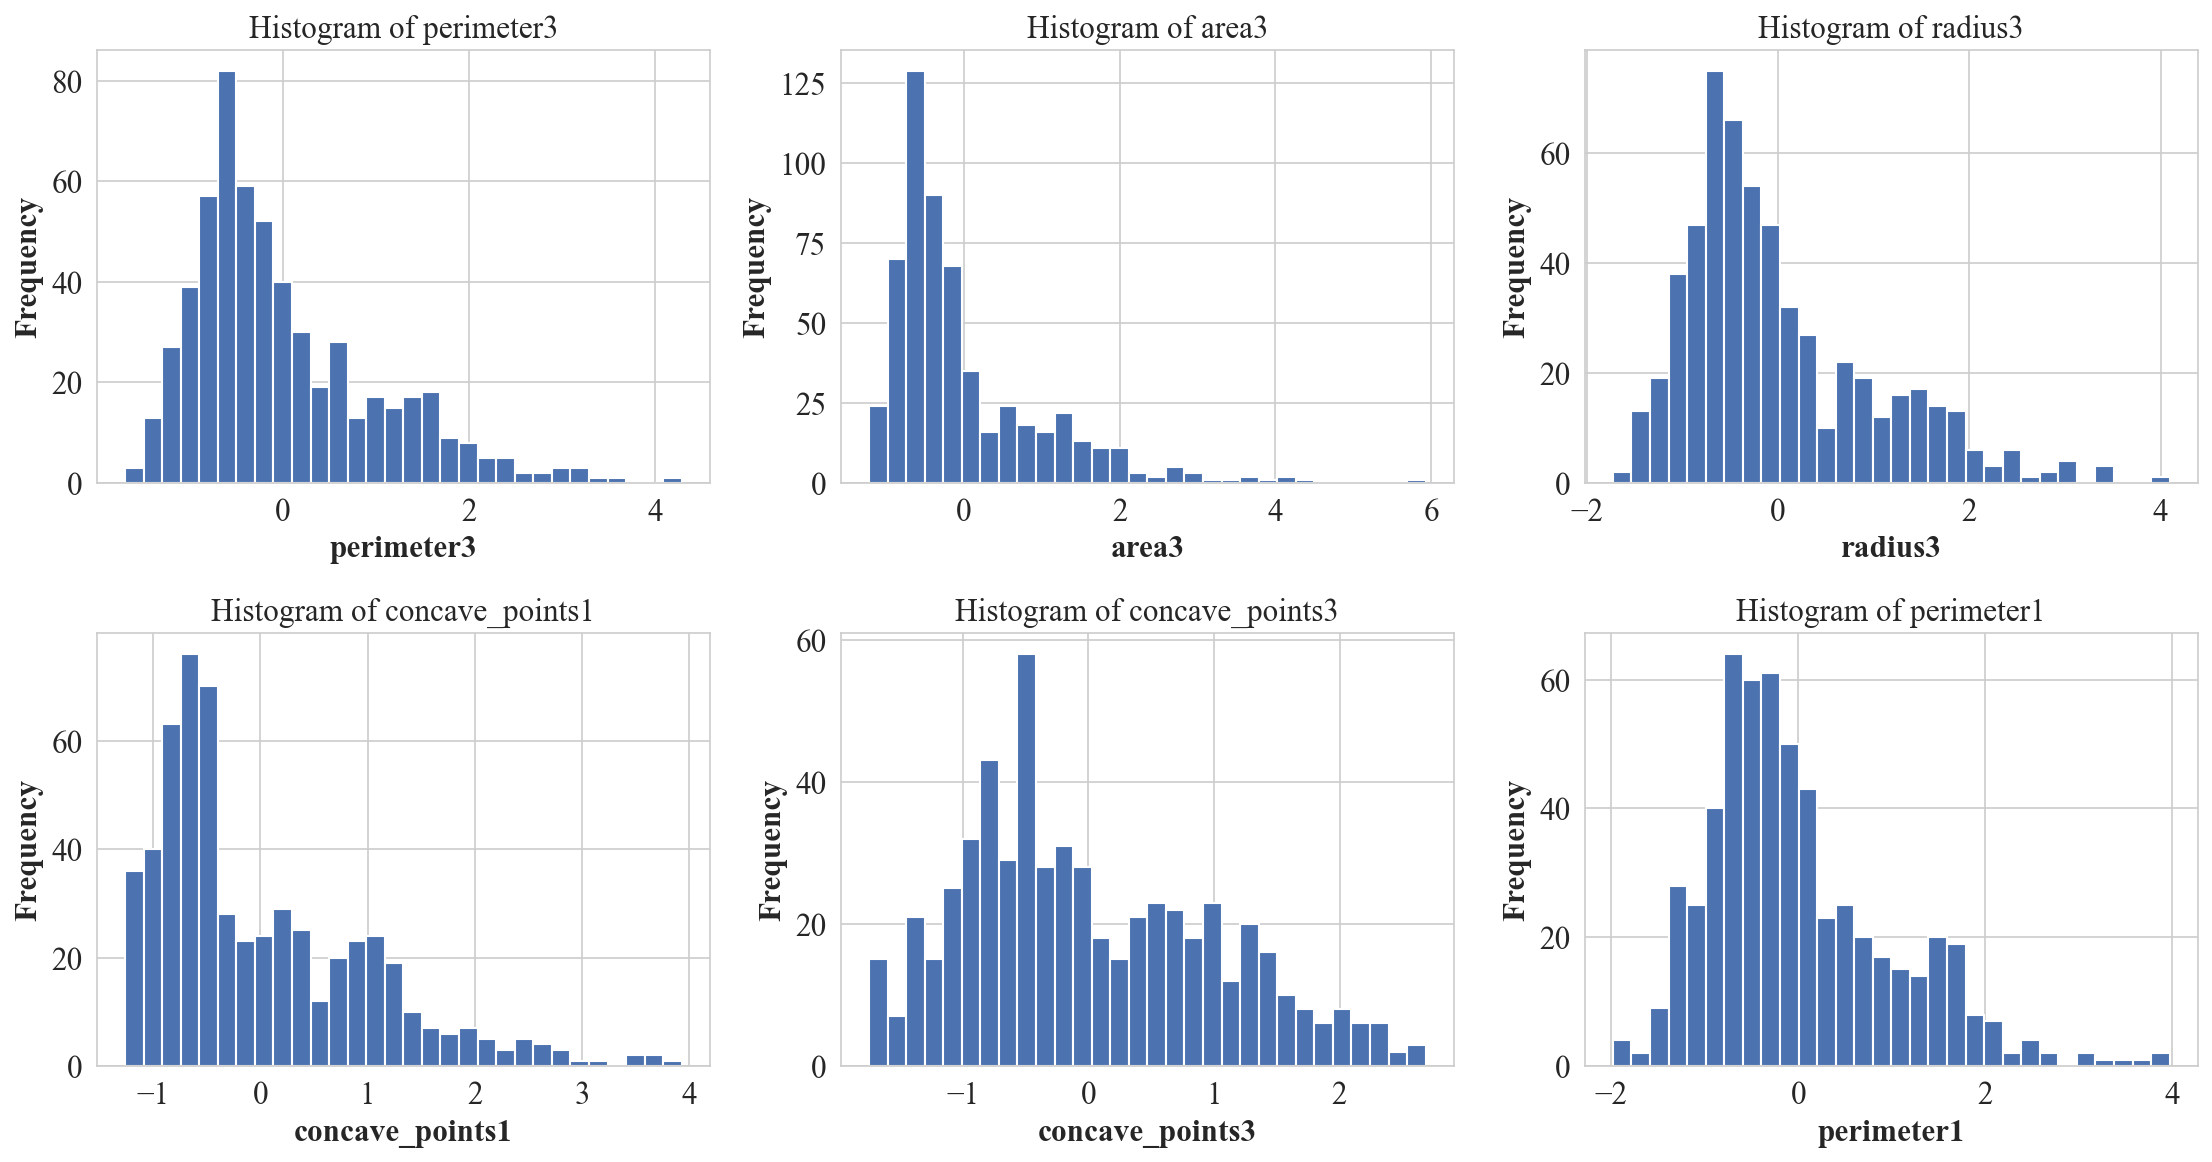

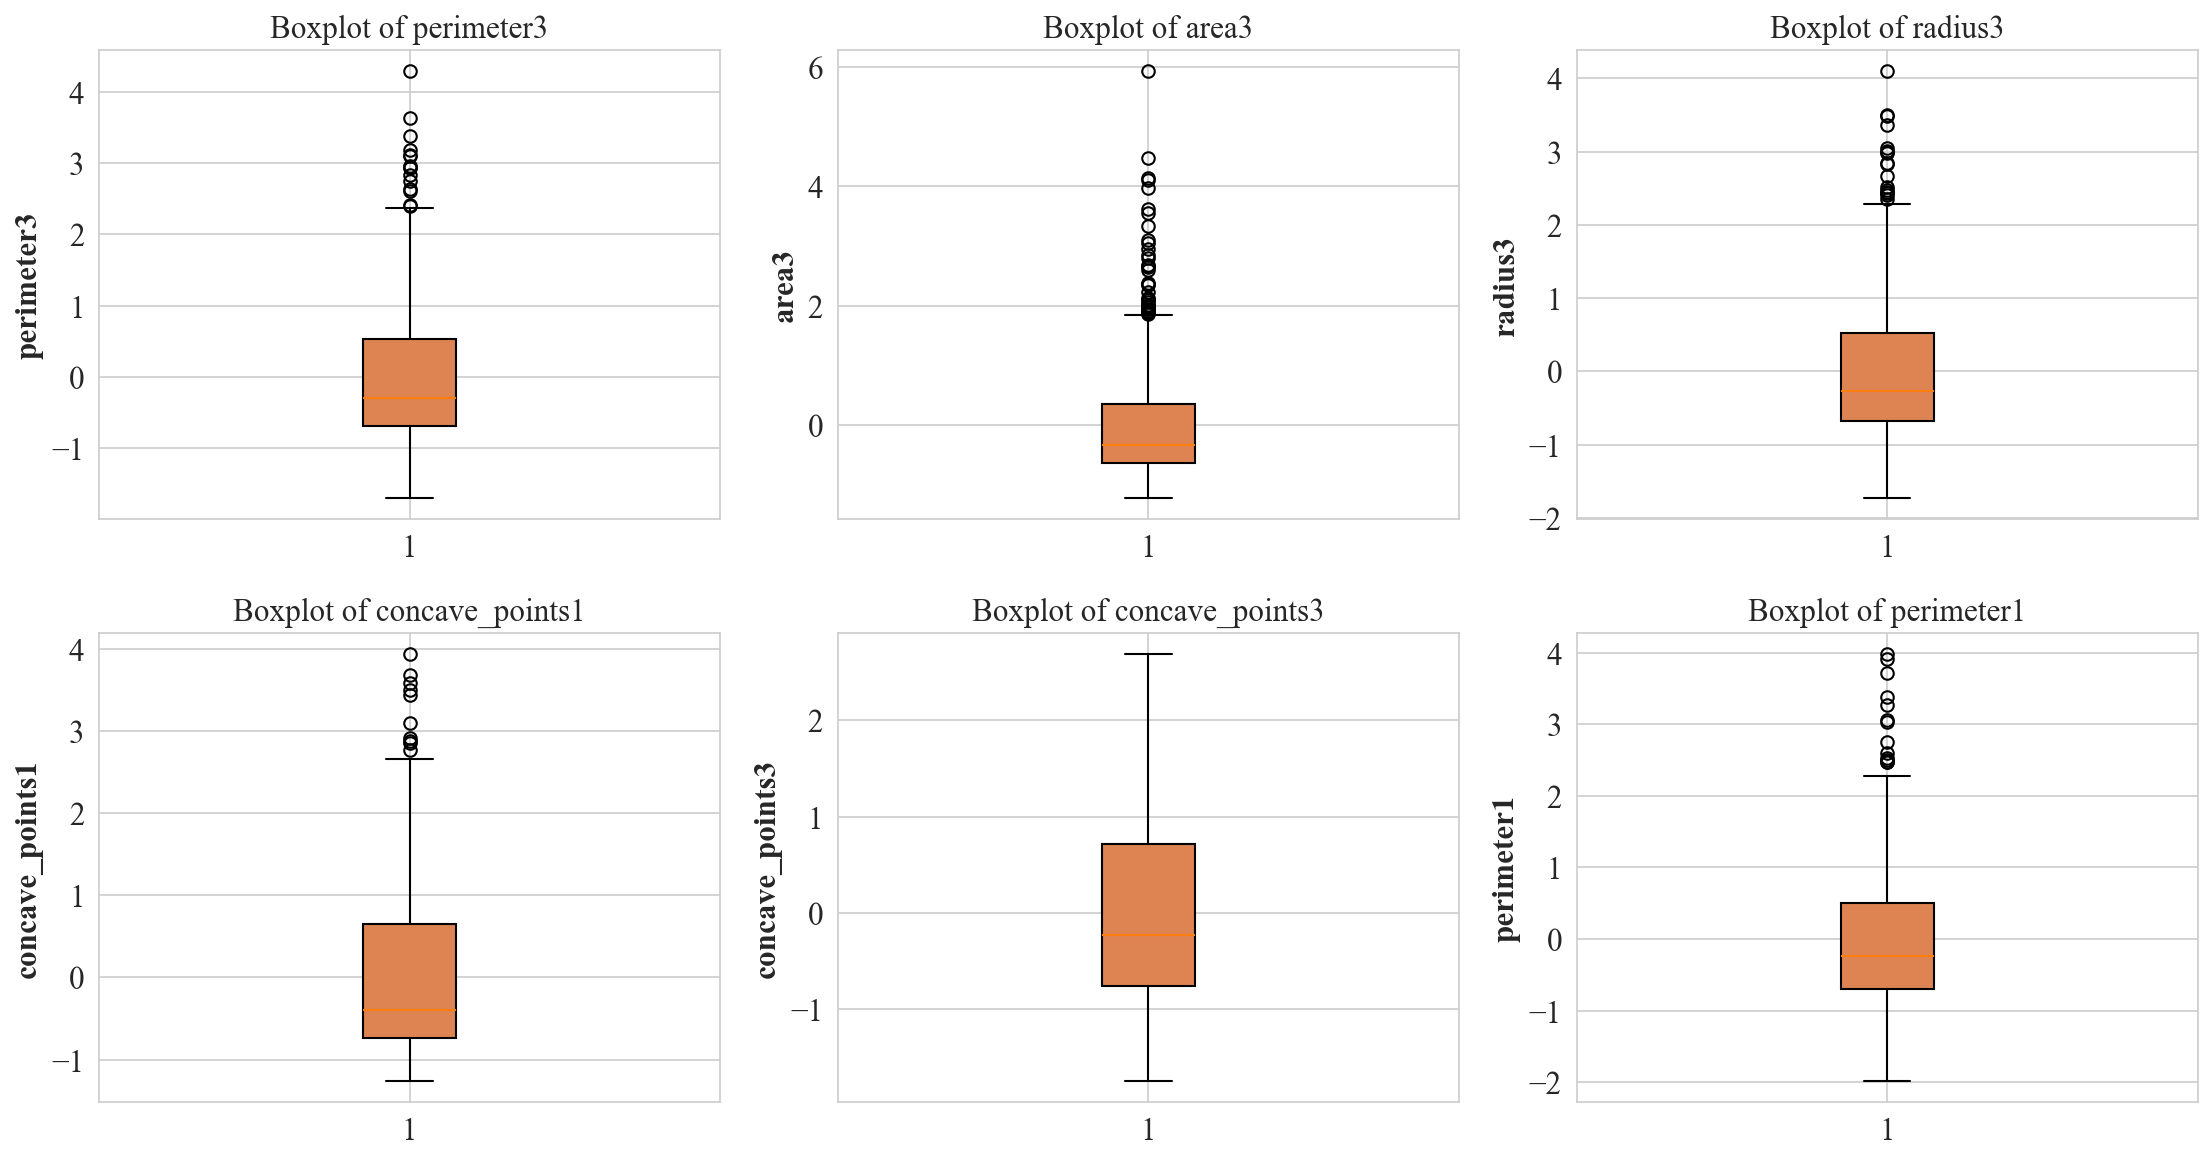

In [5]:
summary=edaSummary(df,target=target)

In [6]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=[target])
y=df[target]
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [7]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay,roc_curve,precision_recall_curve,auc
from sklearn.preprocessing import label_binarize

fontname='Times New Roman'
if fontname not in {f.name for f in fm.fontManager.ttflist}:
    warnings.warn(f"{fontname} not found, using DejaVu Serif")
    fontname='DejaVu Serif'

singlesize=(8,5)

def setGraphStyle():
    sns.set_style('whitegrid')
    plt.rcParams['font.family']=fontname
    plt.rcParams['font.size']=15
    plt.rcParams['axes.labelweight']='bold'
    plt.rcParams['axes.titlesize']=15
    plt.rcParams['figure.dpi']=150

def evaluateModel(model,X_train,X_test,y_train,y_test,name="Model"):
    start=time.perf_counter()
    model.fit(X_train,y_train)
    train_time=time.perf_counter()-start
    start=time.perf_counter()
    y_pred=model.predict(X_test)
    pred_time=time.perf_counter()-start
    metrics={"Model":name,"Accuracy":accuracy_score(y_test,y_pred),"Precision":precision_score(y_test,y_pred,average='weighted',zero_division=0),"Recall":recall_score(y_test,y_pred,average='weighted',zero_division=0),"F1 Score":f1_score(y_test,y_pred,average='weighted',zero_division=0),"Training Time":train_time,"Prediction Time":pred_time}
    y_prob=None
    if hasattr(model,"predict_proba"):
        y_prob=model.predict_proba(X_test)
        try:
            if pd.Series(y_test).nunique()==2:
                metrics["ROC-AUC"]=roc_auc_score(y_test,y_prob[:,1])
            else:
                metrics["ROC-AUC"]=roc_auc_score(y_test,y_prob,multi_class="ovr",average="weighted")
        except Exception:
            metrics["ROC-AUC"]=None
    metrics["Confusion Matrix"]=confusion_matrix(y_test,y_pred)
    return metrics,y_pred,y_prob

def runModels(models,X_train,X_test,y_train,y_test):
    results={}
    trained_models={}
    for name,model in models.items():
        metrics,y_pred,y_prob=evaluateModel(model,X_train,X_test,y_train,y_test,name)
        results[name]=metrics
        trained_models[name]=model
    return pd.DataFrame(results).T,trained_models

def printMetrics(metrics):
    print("Accuracy :",metrics["Accuracy"])
    print("Precision :",metrics["Precision"])
    print("Recall :",metrics["Recall"])
    print("F1 Score :",metrics["F1 Score"])
    print("Training Time :",metrics["Training Time"])
    print("Prediction Time :",metrics["Prediction Time"])

def plotConfusionMatrices(trained_models,X_test,y_test):
    setGraphStyle()
    for name,model in trained_models.items():
        y_pred=model.predict(X_test)
        cm=confusion_matrix(y_test,y_pred)
        fig,ax=plt.subplots(figsize=singlesize)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues",ax=ax)
        ax.set_title(f"Confusion Matrix - {name}")
        plt.show()
        plt.close(fig)

def plotROCCurves(trained_models,X_test,y_test):
    setGraphStyle()
    classes=sorted(pd.Series(y_test).unique())
    fig,ax=plt.subplots(figsize=singlesize)
    if len(classes)==2:
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)[:,1]
            fpr,tpr,_=roc_curve(y_test,y_prob)
            ax.plot(fpr,tpr,label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    else:
        y_bin=label_binarize(y_test,classes=classes)
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)
            fpr,tpr,_=roc_curve(y_bin.ravel(),y_prob.ravel())
            ax.plot(fpr,tpr,label=f"{name} (micro-avg AUC={auc(fpr,tpr):.3f})")
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()
    plt.show()
    plt.close(fig)

def plotPRCurves(trained_models,X_test,y_test):
    setGraphStyle()
    classes=sorted(pd.Series(y_test).unique())
    fig,ax=plt.subplots(figsize=singlesize)
    if len(classes)==2:
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)[:,1]
            precision,recall,_=precision_recall_curve(y_test,y_prob)
            ax.plot(recall,precision,label=name)
    else:
        y_bin=label_binarize(y_test,classes=classes)
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)
            precision,recall,_=precision_recall_curve(y_bin.ravel(),y_prob.ravel())
            ax.plot(recall,precision,label=f"{name} (micro-avg)")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision Recall Curve")
    ax.legend()
    plt.show()
    plt.close(fig)

def plotAccuracyVsK(results_KNN,title="Accuracy vs k"):
    setGraphStyle()
    k=list(results_KNN.keys())
    accuracy=[results_KNN[i]["Accuracy"] for i in k]
    fig,ax=plt.subplots(figsize=singlesize)
    ax.plot(k,accuracy,marker='o')
    ax.set_xlabel("k")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True)
    plt.show()
    plt.close(fig)

def plotCVFolds(cv_df,title="Cross-Validation Accuracy"):
    setGraphStyle()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.plot(cv_df['Fold'],cv_df['Train Accuracy'],marker='o',label='Train Accuracy')
    ax.plot(cv_df['Fold'],cv_df['Validation Accuracy'],marker='o',label='Validation Accuracy')
    ax.set_xlabel("Fold")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.show()
    plt.close(fig)

def plotBarComparison(results_df,column,ylabel,title):
    setGraphStyle()
    names=list(results_df.index)
    values=results_df[column].tolist()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(names,values)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x',rotation=15,labelsize=10)
    plt.show()
    plt.close(fig)

def plotGridSearchHeatmap(grid,param_x,param_y,title="GridSearchCV Heatmap"):
    setGraphStyle()
    res=pd.DataFrame(grid.cv_results_)
    pivot=res.pivot_table(values='mean_test_score',index=f'param_{param_y}',columns=f'param_{param_x}',aggfunc='mean')
    fig,ax=plt.subplots(figsize=singlesize)
    sns.heatmap(pivot,annot=True,fmt='.3f',cmap='viridis',ax=ax,annot_kws={'fontsize':9,'fontname':fontname})
    ax.set_title(title)
    ax.set_xlabel(param_x)
    ax.set_ylabel(param_y)
    plt.show()
    plt.close(fig)

def plotRandomSearchDistribution(search,title="RandomizedSearchCV Score Distribution"):
    setGraphStyle()
    scores=search.cv_results_['mean_test_score']
    fig,ax=plt.subplots(figsize=singlesize)
    ax.hist(scores,bins=10,color='#4C72B0',edgecolor='white')
    ax.axvline(search.best_score_,color='red',linestyle='--',label=f'Best Score={search.best_score_:.3f}')
    ax.set_xlabel("Mean CV Accuracy")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend()
    plt.show()
    plt.close(fig)

Components kept: 10
Explained variance: 0.9523480760221692


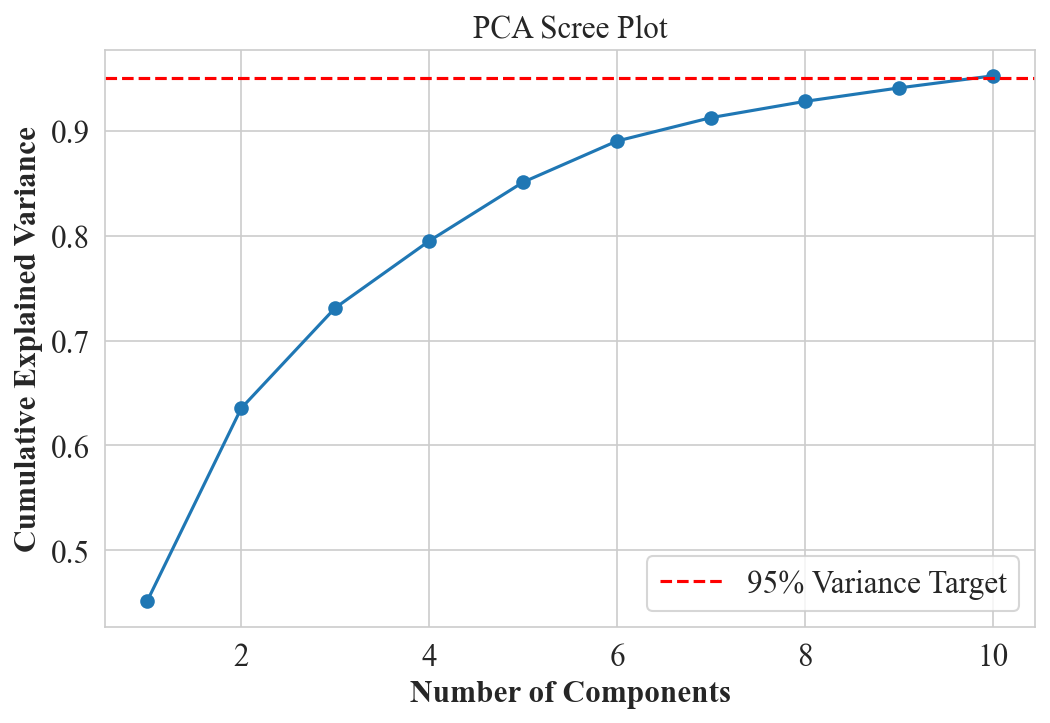

In [8]:
from sklearn.decomposition import PCA

pca=PCA(n_components=0.95,random_state=42)
XtrainPCA=pca.fit_transform(Xtrain)
XtestPCA=pca.transform(Xtest)
print('Components kept:',pca.n_components_)
print('Explained variance:',pca.explained_variance_ratio_.sum())

def plotScreePlot(pca):
    setGraphStyle()
    fig,ax=plt.subplots(figsize=singlesize)
    cumvar=np.cumsum(pca.explained_variance_ratio_)
    ax.plot(range(1,len(cumvar)+1),cumvar,marker='o')
    ax.axhline(0.95,color='red',linestyle='--',label='95% Variance Target')
    ax.set_xlabel('Number of Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.set_title('PCA Scree Plot')
    ax.legend()
    plt.show()
    plt.close(fig)

plotScreePlot(pca)

In [9]:
import time
from sklearn.model_selection import GridSearchCV,cross_validate
from sklearn.metrics import accuracy_score,f1_score

def tuneEvaluate(model,paramGrid,Xtr,Xte,ytr,yte,name):
    search=GridSearchCV(model,paramGrid,cv=5,scoring='accuracy',n_jobs=-1)
    search.fit(Xtr,ytr)
    best=search.best_estimator_
    cvres=cross_validate(best,Xtr,ytr,cv=5,scoring='accuracy',return_train_score=True)
    ypred=best.predict(Xte)
    return {'name':name,'best_params':search.best_params_,'cv_scores':cvres['test_score'],
    'cv_mean':cvres['test_score'].mean(),'test_acc':accuracy_score(yte,ypred),
    'test_f1':f1_score(yte,ypred),'model':best}

In [10]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

models={
'SVM':(SVC(probability=True),{'C':[1,10,100],'kernel':['rbf'],'gamma':['scale','auto']}),
'Naive Bayes':(GaussianNB(),{'var_smoothing':[1e-9,1e-8,1e-7]}),
'KNN':(KNeighborsClassifier(),{'n_neighbors':[3,5,7,9],'weights':['uniform','distance']}),
'Logistic Regression':(LogisticRegression(max_iter=1000),{'C':[0.1,1,10]}),
'Decision Tree':(DecisionTreeClassifier(random_state=42),{'max_depth':[3,5,7,None]}),
'Random Forest':(RandomForestClassifier(random_state=42),{'n_estimators':[50,100,150]}),
'AdaBoost':(AdaBoostClassifier(random_state=42),{'n_estimators':[50,100],'learning_rate':[0.1,1.0]}),
'Gradient Boosting':(GradientBoostingClassifier(random_state=42),{'n_estimators':[50,100],'learning_rate':[0.05,0.1]}),
'XGBoost':(XGBClassifier(eval_metric='logloss',random_state=42),{'n_estimators':[50,100],'max_depth':[3,5]})
}

In [11]:
from sklearn.ensemble import StackingClassifier

stackModel=StackingClassifier(
estimators=[('svm',SVC(probability=True)),('nb',GaussianNB()),('dt',DecisionTreeClassifier())],
final_estimator=LogisticRegression(max_iter=1000),cv=5)
stackGrid={'final_estimator__C':[0.1,1,10]}

In [12]:
resultsNoPCA={}
for name,(model,grid) in models.items():
    resultsNoPCA[name]=tuneEvaluate(model,grid,Xtrain,Xtest,ytrain,ytest,name)
    print(name,'done -',resultsNoPCA[name]['test_acc'])

resultsNoPCA['Stacking']=tuneEvaluate(stackModel,stackGrid,Xtrain,Xtest,ytrain,ytest,'Stacking')
print('Stacking done -',resultsNoPCA['Stacking']['test_acc'])

SVM done - 0.9736842105263158
Naive Bayes done - 0.9210526315789473
KNN done - 0.9385964912280702
Logistic Regression done - 0.9649122807017544
Decision Tree done - 0.9385964912280702
Random Forest done - 0.9736842105263158
AdaBoost done - 0.9824561403508771
Gradient Boosting done - 0.956140350877193
XGBoost done - 0.9649122807017544
Stacking done - 0.9824561403508771


In [13]:
resultsPCA={}
for name,(model,grid) in models.items():
    resultsPCA[name]=tuneEvaluate(model,grid,XtrainPCA,XtestPCA,ytrain,ytest,name)
    print(name,'done -',resultsPCA[name]['test_acc'])

resultsPCA['Stacking']=tuneEvaluate(stackModel,stackGrid,XtrainPCA,XtestPCA,ytrain,ytest,'Stacking')
print('Stacking done -',resultsPCA['Stacking']['test_acc'])

SVM done - 0.9649122807017544
Naive Bayes done - 0.8947368421052632
KNN done - 0.9473684210526315
Logistic Regression done - 0.9824561403508771
Decision Tree done - 0.9122807017543859
Random Forest done - 0.9385964912280702
AdaBoost done - 0.9473684210526315
Gradient Boosting done - 0.9473684210526315
XGBoost done - 0.956140350877193
Stacking done - 0.956140350877193


In [14]:
rows=[]
for name in resultsNoPCA:
    npca=resultsNoPCA[name]
    pca_=resultsPCA[name]
    row={'Model':name}
    for i in range(5):
        row[f'Fold {i+1} (NoPCA)']=npca['cv_scores'][i]
    row['Avg (NoPCA)']=npca['cv_mean']
    row['Avg (WithPCA)']=pca_['cv_mean']
    rows.append(row)
table5=pd.DataFrame(rows)
print(table5)

                 Model  Fold 1 (NoPCA)  Fold 2 (NoPCA)  Fold 3 (NoPCA)  \
0                  SVM        0.967033        1.000000        0.967033   
1          Naive Bayes        0.923077        0.989011        0.923077   
2                  KNN        0.978022        1.000000        0.945055   
3  Logistic Regression        0.967033        0.989011        0.956044   
4        Decision Tree        0.978022        0.967033        0.912088   
5        Random Forest        1.000000        0.989011        0.934066   
6             AdaBoost        0.978022        0.989011        0.923077   
7    Gradient Boosting        1.000000        1.000000        0.923077   
8              XGBoost        0.989011        0.989011        0.934066   
9             Stacking        0.978022        1.000000        0.956044   

   Fold 4 (NoPCA)  Fold 5 (NoPCA)  Avg (NoPCA)  Avg (WithPCA)  
0        0.956044        0.978022     0.973626       0.973626  
1        0.923077        0.934066     0.938462       0.91

In [15]:
paramRows=[]
for name in resultsNoPCA:
    paramRows.append({'Model':name,'Best Params (NoPCA)':resultsNoPCA[name]['best_params'],
    'Best Params (WithPCA)':resultsPCA[name]['best_params'],
    'Test Accuracy (NoPCA)':resultsNoPCA[name]['test_acc'],
    'Test Accuracy (WithPCA)':resultsPCA[name]['test_acc'],
    'Test F1 (NoPCA)':resultsNoPCA[name]['test_f1'],
    'Test F1 (WithPCA)':resultsPCA[name]['test_f1']})
paramTable=pd.DataFrame(paramRows)
print(paramTable)

                 Model                          Best Params (NoPCA)  \
0                  SVM  {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}   
1          Naive Bayes                     {'var_smoothing': 1e-09}   
2                  KNN     {'n_neighbors': 3, 'weights': 'uniform'}   
3  Logistic Regression                                     {'C': 1}   
4        Decision Tree                             {'max_depth': 7}   
5        Random Forest                         {'n_estimators': 50}   
6             AdaBoost   {'learning_rate': 1.0, 'n_estimators': 50}   
7    Gradient Boosting   {'learning_rate': 0.1, 'n_estimators': 50}   
8              XGBoost         {'max_depth': 3, 'n_estimators': 50}   
9             Stacking                   {'final_estimator__C': 10}   

                          Best Params (WithPCA)  Test Accuracy (NoPCA)  \
0   {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}               0.973684   
1                      {'var_smoothing': 1e-09}               0.921053

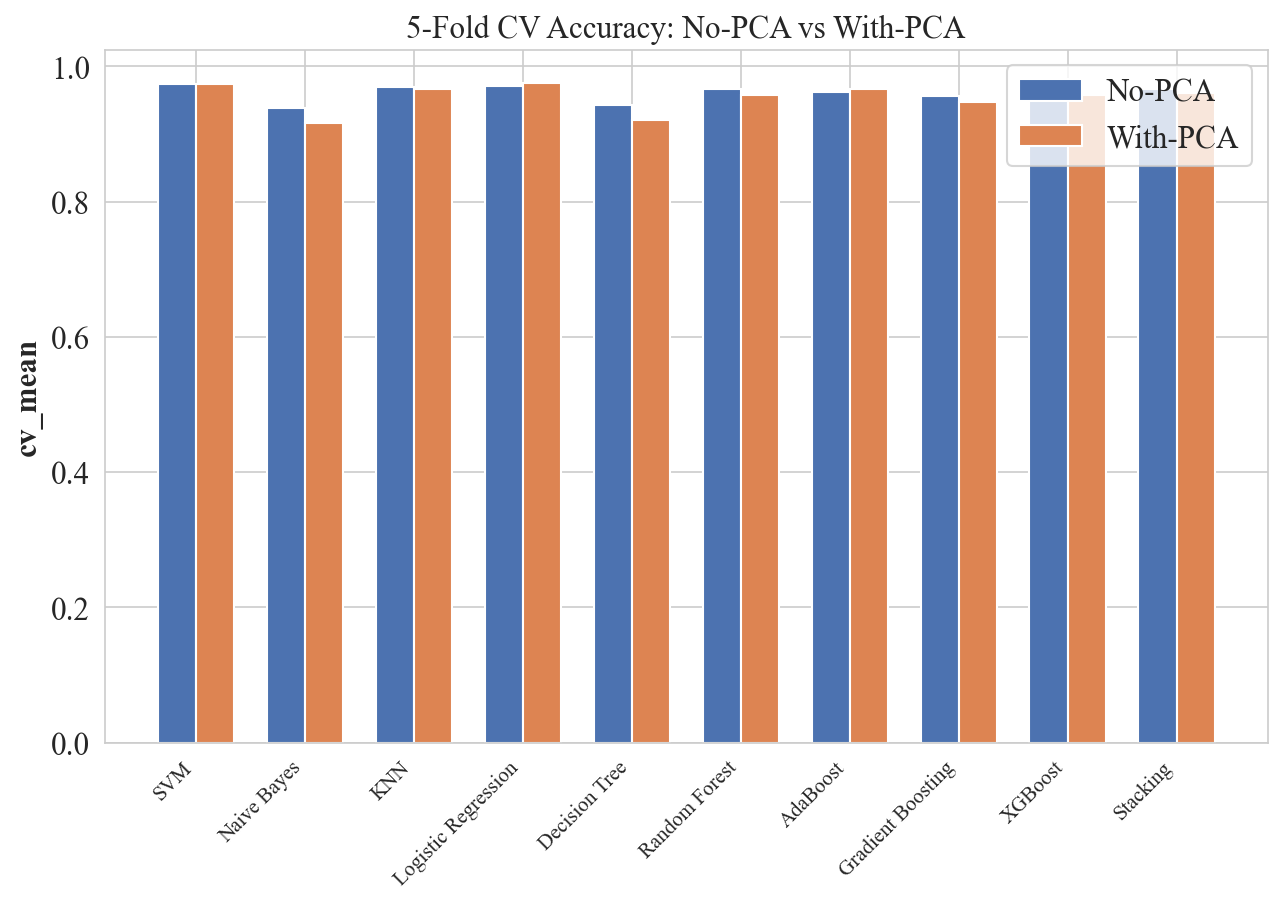

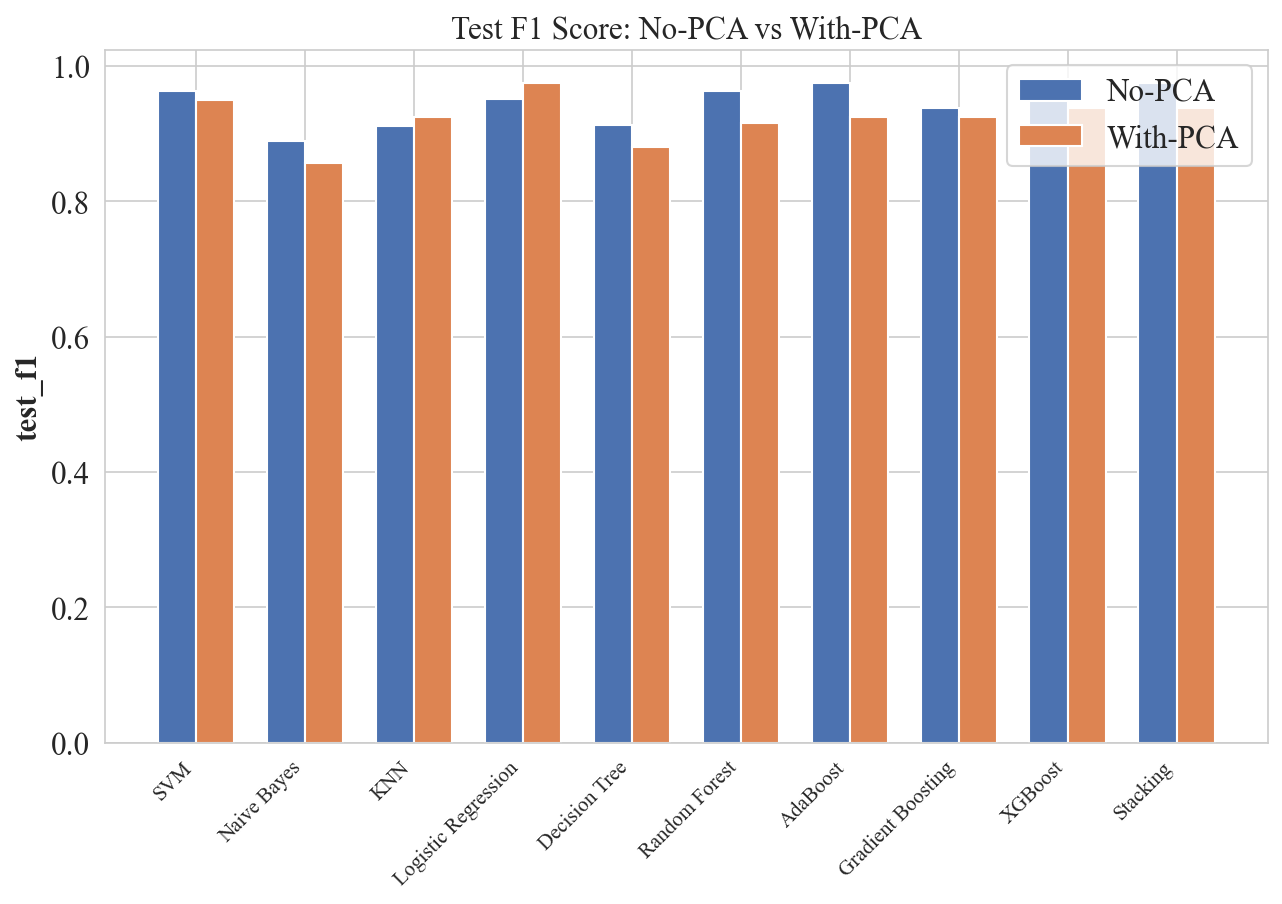

In [16]:
def plotPCAComparison(resultsNoPCA,resultsPCA,metric,title):
    setGraphStyle()
    names=list(resultsNoPCA.keys())
    noPCAVals=[resultsNoPCA[n][metric] for n in names]
    pcaVals=[resultsPCA[n][metric] for n in names]
    x=np.arange(len(names))
    width=0.35
    fig,ax=plt.subplots(figsize=(10,6))
    ax.bar(x-width/2,noPCAVals,width,label='No-PCA',color='#4C72B0')
    ax.bar(x+width/2,pcaVals,width,label='With-PCA',color='#DD8452')
    ax.set_xticks(x)
    ax.set_xticklabels(names,rotation=45,ha='right',fontsize=10)
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    plt.show()
    plt.close(fig)

plotPCAComparison(resultsNoPCA,resultsPCA,'cv_mean','5-Fold CV Accuracy: No-PCA vs With-PCA')
plotPCAComparison(resultsNoPCA,resultsPCA,'test_f1','Test F1 Score: No-PCA vs With-PCA')

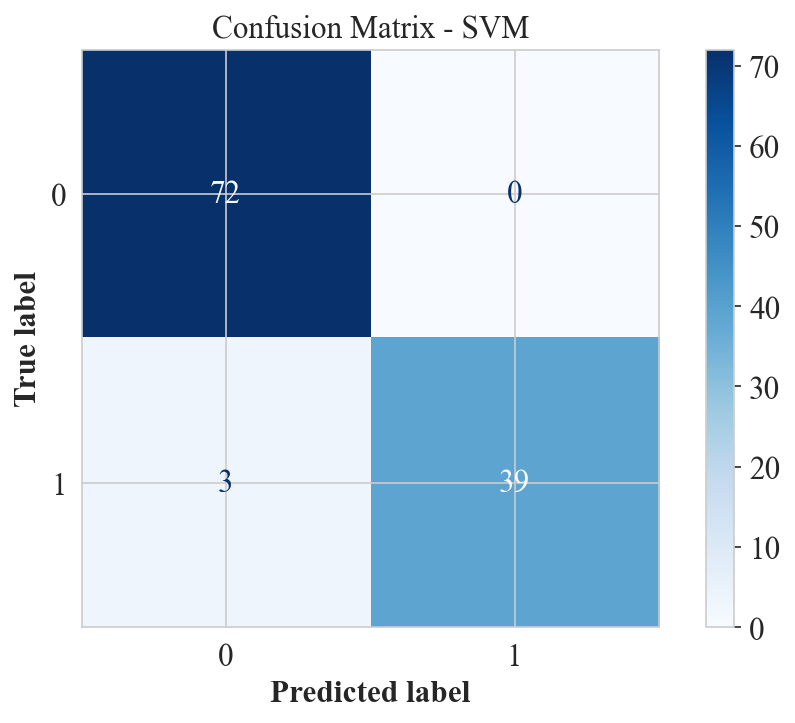

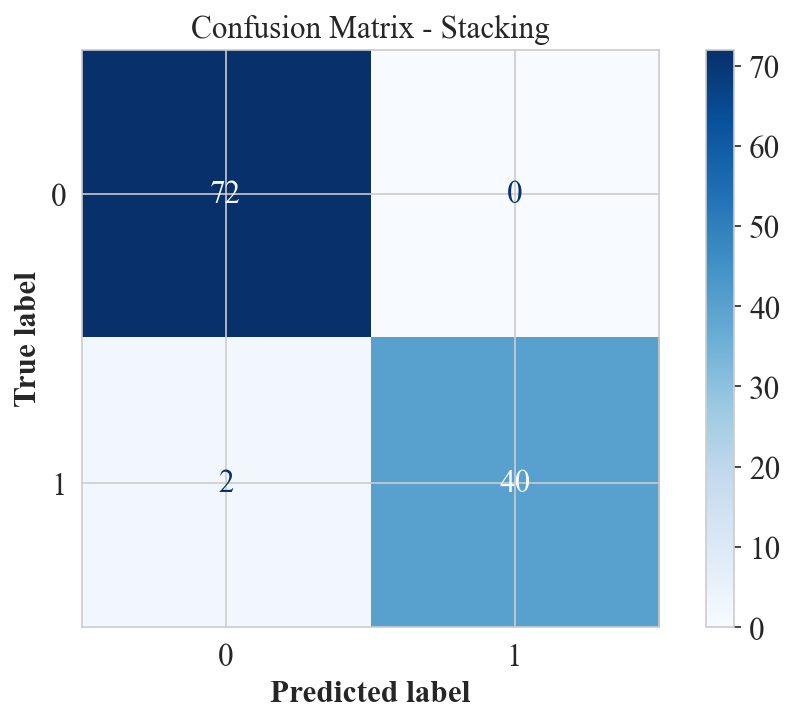

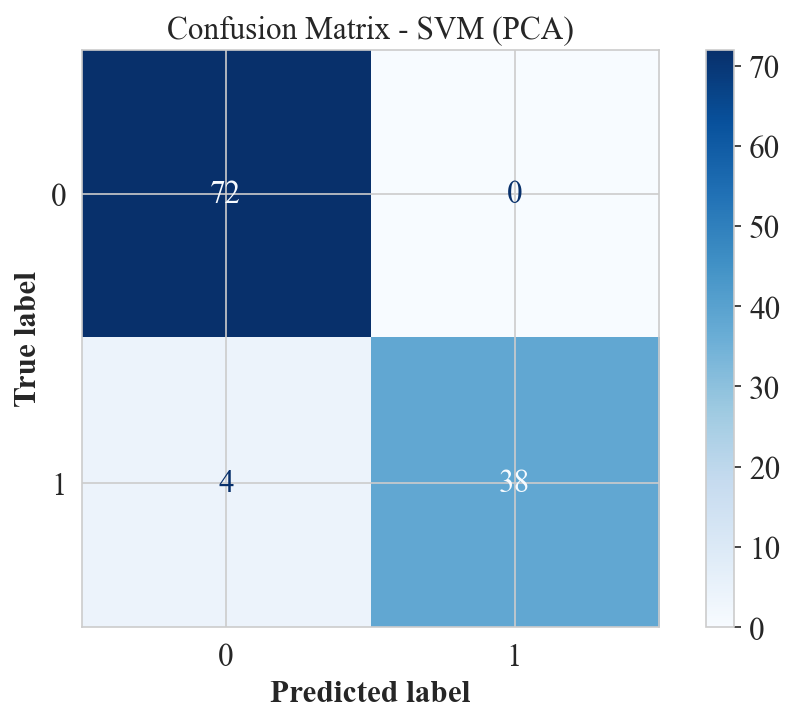

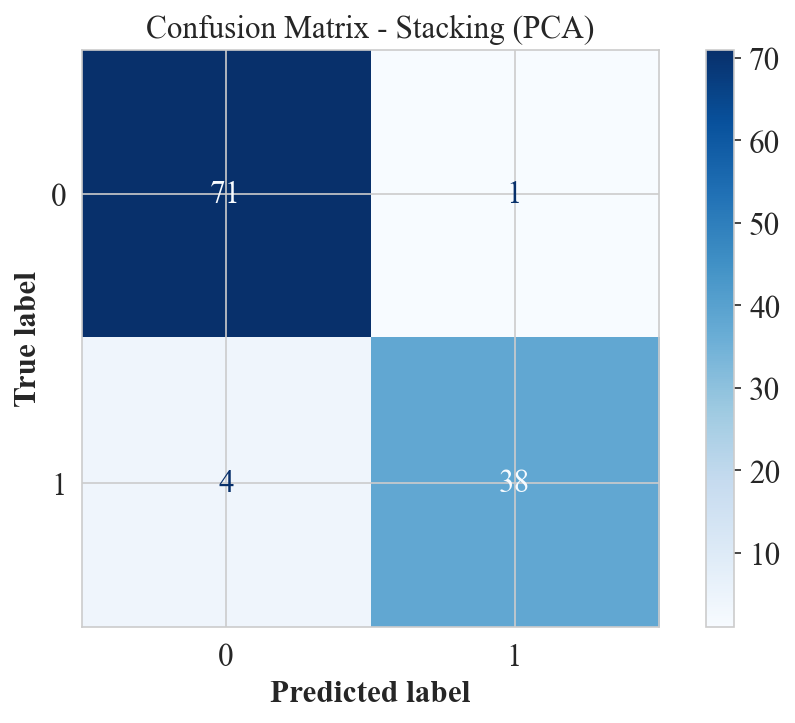

In [17]:
selectedNoPCA={'SVM':resultsNoPCA['SVM']['model'],'Stacking':resultsNoPCA['Stacking']['model']}
selectedPCA={'SVM (PCA)':resultsPCA['SVM']['model'],'Stacking (PCA)':resultsPCA['Stacking']['model']}

plotConfusionMatrices(selectedNoPCA,Xtest,ytest)
plotConfusionMatrices(selectedPCA,XtestPCA,ytest)

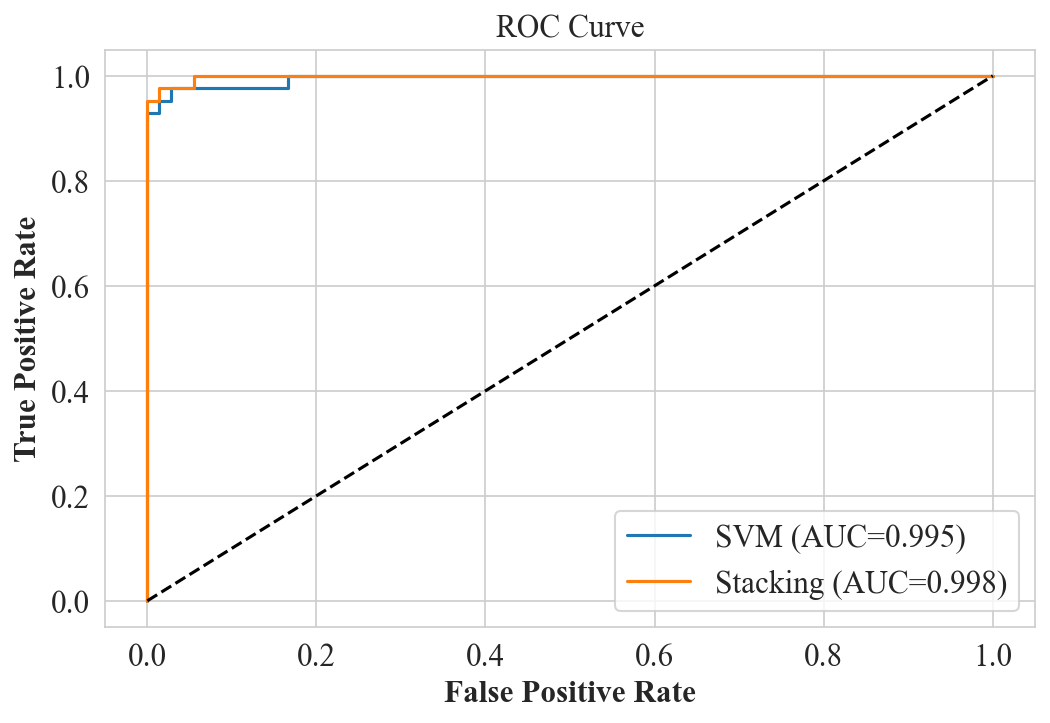

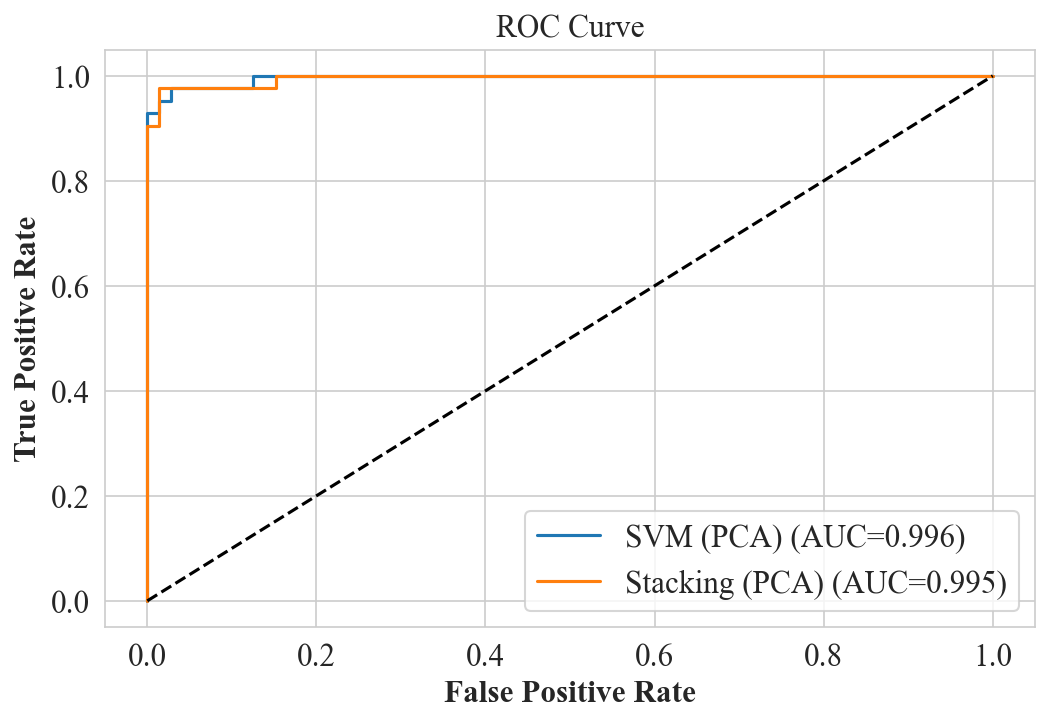

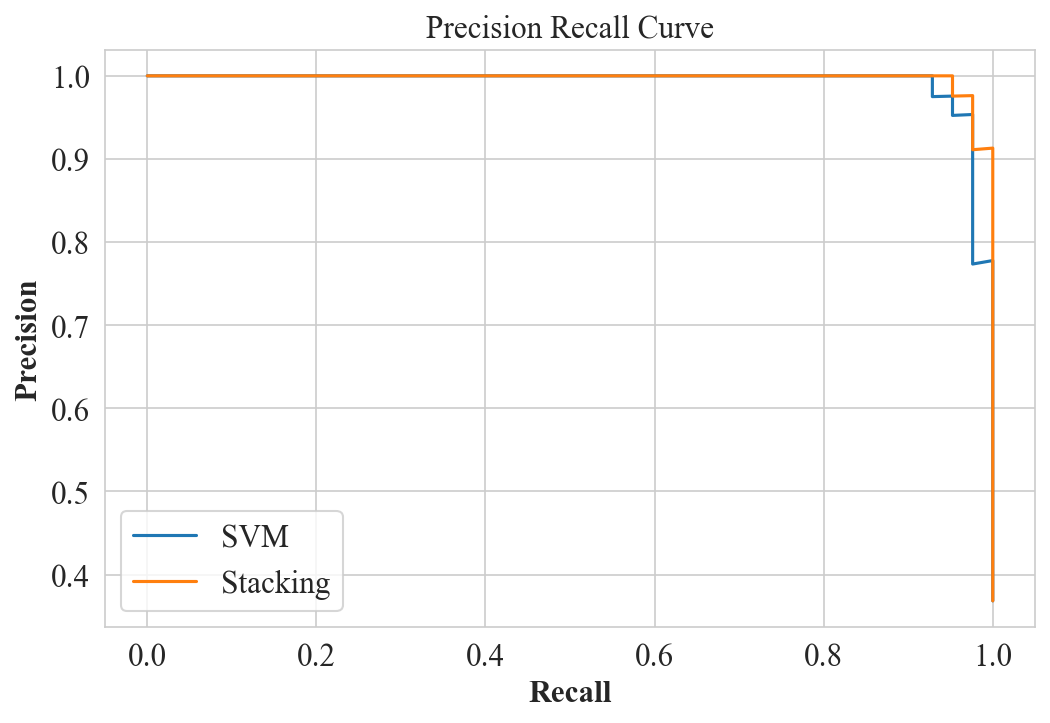

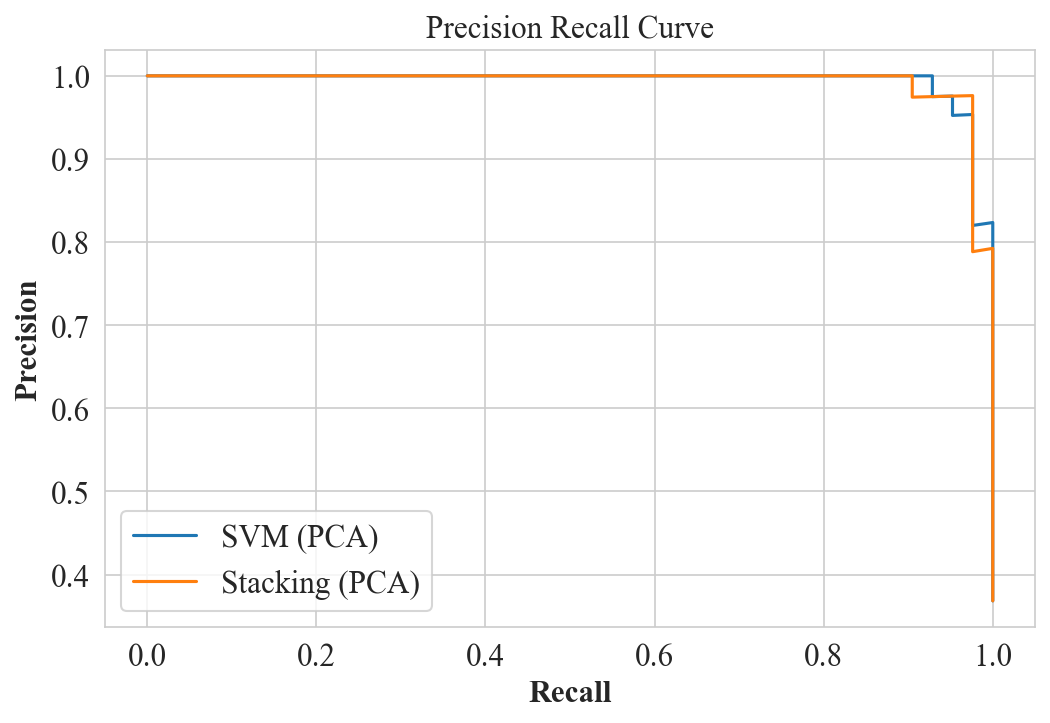

In [18]:
plotROCCurves(selectedNoPCA,Xtest,ytest)
plotROCCurves(selectedPCA,XtestPCA,ytest)
plotPRCurves(selectedNoPCA,Xtest,ytest)
plotPRCurves(selectedPCA,XtestPCA,ytest)

In [19]:
corr=np.corrcoef(Xtrain,rowvar=False)
n=corr.shape[0]
avgcorr=(np.abs(corr).sum()-n)/(n*n-n)
print('Average correlation between features:',avgcorr)

Average correlation between features: 0.3965505770201823


In [20]:
varTable=pd.DataFrame({'Component':range(1,pca.n_components_+1),
'Variance Explained (%)':pca.explained_variance_ratio_*100,
'Cumulative (%)':np.cumsum(pca.explained_variance_ratio_)*100})
print(varTable)

   Component  Variance Explained (%)  Cumulative (%)
0          1               45.182689       45.182689
1          2               18.362334       63.545024
2          3                9.564943       73.109967
3          4                6.375645       79.485612
4          5                5.609276       85.094888
5          6                3.923136       89.018024
6          7                2.230015       91.248039
7          8                1.550017       92.798057
8          9                1.283073       94.081130
9         10                1.153678       95.234808


In [22]:
from scipy import stats

sigRows=[]
for name in resultsNoPCA:
    noPCAScores=resultsNoPCA[name]['cv_scores']
    pcaScores=resultsPCA[name]['cv_scores']
    tstat,tpval=stats.ttest_rel(noPCAScores,pcaScores)
    try:
        wstat,wpval=stats.wilcoxon(noPCAScores,pcaScores)
    except ValueError:
        wstat,wpval=np.nan,np.nan
    sigRows.append({'Model':name,
    'Mean CV (NoPCA)':noPCAScores.mean(),
    'Mean CV (WithPCA)':pcaScores.mean(),
    'T-test p-value':tpval,
    'Wilcoxon p-value':wpval,
    'Significant (p<0.05)':'Yes' if tpval<0.05 else 'No'})

sigTable=pd.DataFrame(sigRows)
print(sigTable)

                 Model  Mean CV (NoPCA)  Mean CV (WithPCA)  T-test p-value  \
0                  SVM         0.973626           0.973626        1.000000   
1          Naive Bayes         0.938462           0.916484        0.102700   
2                  KNN         0.969231           0.967033        0.373901   
3  Logistic Regression         0.971429           0.975824        0.177808   
4        Decision Tree         0.942857           0.920879        0.290441   
5        Random Forest         0.967033           0.958242        0.707536   
6             AdaBoost         0.962637           0.967033        0.670180   
7    Gradient Boosting         0.956044           0.947253        0.770045   
8              XGBoost         0.969231           0.958242        0.518519   
9             Stacking         0.967033           0.960440        0.552889   

   Wilcoxon p-value Significant (p<0.05)  
0             1.000                   No  
1             0.125                   No  
2           

In [23]:
stabilityRows=[]
for name in resultsNoPCA:
    noPCAScores=resultsNoPCA[name]['cv_scores']
    pcaScores=resultsPCA[name]['cv_scores']
    fstat,fpval=stats.levene(noPCAScores,pcaScores)
    stabilityRows.append({'Model':name,
    'Std Dev (NoPCA)':noPCAScores.std(),
    'Std Dev (WithPCA)':pcaScores.std(),
    'More Stable':'WithPCA' if pcaScores.std()<noPCAScores.std() else 'NoPCA',
    'Levene p-value':fpval,
    'Stability Difference Significant (p<0.05)':'Yes' if fpval<0.05 else 'No'})

stabilityTable=pd.DataFrame(stabilityRows)
print(stabilityTable)

                 Model  Std Dev (NoPCA)  Std Dev (WithPCA) More Stable  \
0                  SVM         0.014906           0.014906       NoPCA   
1          Naive Bayes         0.025631           0.030769       NoPCA   
2                  KNN         0.021308           0.020850     WithPCA   
3  Logistic Regression         0.011207           0.012815       NoPCA   
4        Decision Tree         0.035027           0.025441     WithPCA   
5        Random Forest         0.031849           0.031391     WithPCA   
6             AdaBoost         0.028317           0.019658     WithPCA   
7    Gradient Boosting         0.037427           0.032151     WithPCA   
8              XGBoost         0.021308           0.028146       NoPCA   
9             Stacking         0.021978           0.022628       NoPCA   

   Levene p-value Stability Difference Significant (p<0.05)  
0        1.000000                                        No  
1        0.633139                                        No  